In [5]:
from pathlib import Path
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [6]:
truth_json_path = "/home/furkan/projects/cpak-legacy/datasets/angle-test/angles.json"

# enter corresponding orthopedic_metrics.json file
inference_json_path = "/home/furkan/projects/cpak-legacy/training/deeplabcut/cpak-furkan-2026-02-20/notebooks/out/inference/sh14-ep1000/orthopedic_metrics.json"

output_folder = "/home/furkan/projects/cpak-legacy/training/deeplabcut/cpak-furkan-2026-02-20/notebooks/out/test/sh14-ep1000"

### Handle truth angles

In [7]:
def truth_file_name_normalizer(filename: str) -> str:
    """
    input: 4075_L_İŞARETLENMİŞ-img-00000-00000.jpg
    output: 4075_l
    """
    # Dosya adını alt tirelerden parçalara ayır
    # ["4075", "L", "İŞARETLENMİŞ-img-00000-00000.jpg"]
    parts = filename.split("_")
    
    if len(parts) >= 2:
        # İlk iki parçayı al: 4075 ve L
        # L harfini küçük harfe çevir (L -> l)
        result = f"{parts[0]}_{parts[1].lower()}"
        return result
    
    return filename # Beklenen formatta değilse orijinali döner

In [8]:
angles_json = {}
truth_angles = {}
with open(truth_json_path, "r", encoding="utf-8") as f:
	json_text = f.read()
	angles_json = json.loads(json_text)
	for key in angles_json.keys():
		truth_angles[truth_file_name_normalizer(key)] = angles_json[key]

truth_angles  # the dictionary which includes clean formatted angles:
# '4075_l': {'femur': '86.34', 'tibia': '83.32'},
# '4076_l': {'femur': '89.34', 'tibia': '88.86'},

{'4075_l': {'femur': '86.34', 'tibia': '83.32'},
 '4076_l': {'femur': '89.34', 'tibia': '88.86'},
 '4076_r': {'femur': '87.81', 'tibia': '87.80'},
 '4077_l': {'femur': '89.76', 'tibia': '86.13'},
 '4077_r': {'femur': '89.50', 'tibia': '85.15'},
 '4078_l': {'femur': '84.41', 'tibia': '86.24'},
 '4078_r': {'femur': '85.68', 'tibia': '87.43'},
 '4079_l': {'femur': '87.28', 'tibia': '88.75'},
 '4079_r': {'femur': '88.19', 'tibia': '84.89'},
 '4080_r': {'femur': '87.05', 'tibia': '82.68'},
 '4081_l': {'femur': '89.24', 'tibia': '80.40'},
 '4082_l': {'femur': '89.16', 'tibia': '82.40'},
 '4082_r': {'femur': '88.06', 'tibia': '85.00'},
 '4083_l': {'femur': '87.45', 'tibia': '88.09'},
 '4083_r': {'femur': '87.69', 'tibia': '87.86'},
 '4084_l': {'femur': '89.59', 'tibia': '86.41'},
 '4084_r': {'femur': '88.35', 'tibia': '87.39'},
 '4085_l': {'femur': '86.04', 'tibia': '86.45'},
 '4085_r': {'femur': '89.99', 'tibia': '89.81'},
 '4086_l': {'femur': '89.31', 'tibia': '89.03'},
 '4086_r': {'femur':

### Handle inference angles

In [9]:
def inference_file_name_normalizer(filename: str) -> str:
	"""
	input: 4000.l.png
	output: 4000_l
	"""

	# Dosya adını ve uzantılarını ayırır (örn: 4000.l.png -> 4000.l)
	name_without_extension = Path(filename).stem

	# Noktayı alt tire ile değiştirir
	formatted_name = name_without_extension.replace(".", "_")

	return formatted_name

In [10]:
orto_metrics = {}
inference_angles = {}
with open(inference_json_path, "r", encoding="utf-8") as f:
	json_text = f.read()
	orto_metrics = json.loads(json_text)
	
	for key in orto_metrics.keys():
		femur_angle_ax_middle = orto_metrics[key]["femur_mech_angle_ax_middle"]
		femur_angle_notch = orto_metrics[key]["femur_mech_angle_notch"]
		femur_angle_ax_middle = round(femur_angle_ax_middle, 2)
		tibia_angle_ax_middle = orto_metrics[key]["tibia_mech_angle_ax_middle"]
		tibia_angle_inter = orto_metrics[key]["tibia_mech_angle_inter"]
		tibia_angle_ax_middle = round(tibia_angle_ax_middle, 2)
		new_key = inference_file_name_normalizer(key)
		inference_angles[new_key] = {
			"femur": {
				"femur_ax_middle":femur_angle_ax_middle, 
				"femur_notch":femur_angle_notch
			},
			"tibia":{
				"tibia_ax_middle":tibia_angle_ax_middle,
				"tibia_inter":tibia_angle_inter
			}
		}

inference_angles  # the dictionary which includes clean formatted angles:
# '4075_l': {'femur': '86.34', 'tibia': '83.32'},
# '4076_l': {'femur': '89.34', 'tibia': '88.86'},

{'4000_l': {'femur': {'femur_ax_middle': 88.3,
   'femur_notch': 88.49956278537525},
  'tibia': {'tibia_ax_middle': 87.41, 'tibia_inter': 86.7830958470301}},
 '4000_r': {'femur': {'femur_ax_middle': 88.4,
   'femur_notch': 88.56682081788784},
  'tibia': {'tibia_ax_middle': 83.89, 'tibia_inter': 83.38766721114132}},
 '4001_l': {'femur': {'femur_ax_middle': 88.38,
   'femur_notch': 88.32584790905165},
  'tibia': {'tibia_ax_middle': 82.1, 'tibia_inter': 81.81484498333549}},
 '4001_r': {'femur': {'femur_ax_middle': 82.7,
   'femur_notch': 82.33074224200807},
  'tibia': {'tibia_ax_middle': 74.79, 'tibia_inter': 74.70308384619491}},
 '4002_l': {'femur': {'femur_ax_middle': 86.14,
   'femur_notch': 86.0574898047667},
  'tibia': {'tibia_ax_middle': 85.18, 'tibia_inter': 84.94855247043118}},
 '4002_r': {'femur': {'femur_ax_middle': 84.74,
   'femur_notch': 84.4816336118604},
  'tibia': {'tibia_ax_middle': 89.45, 'tibia_inter': 89.26653150650561}},
 '4003_l': {'femur': {'femur_ax_middle': 85.78,

## Create all values dataframe

In [11]:
def create_comparison_df(gt_dict, pred_dict, output_folder):
    """
    Creates a comparison DataFrame and handles potential string-to-float conversions.
    """
    common_keys = sorted(list(set(gt_dict.keys()) & set(pred_dict.keys())))

    if not os.path.exists(output_folder):
        os.makedirs(output_folder, exist_ok=True)
    
    data = []
    for key in common_keys:
        row = {'id': key}
        
        # --- FEMUR CALCULATIONS ---
        # Ensure GT is a float even if it's stored as a string
        try:
            f_gt_raw = gt_dict[key].get('femur')
            f_gt_val = float(f_gt_raw) if f_gt_raw is not None else None
        except (ValueError, TypeError):
            f_gt_val = None

        f_ax_pred = pred_dict[key]['femur'].get('femur_ax_middle')
        f_notch_pred = pred_dict[key]['femur'].get('femur_notch')

        f_ax_err = abs(f_gt_val - f_ax_pred) if (f_gt_val is not None and f_ax_pred is not None) else None
        f_notch_err = abs(f_gt_val - f_notch_pred) if (f_gt_val is not None and f_notch_pred is not None) else None

        row.update({
            'f_gt': f_gt_val,
            'f_ax_pred': f_ax_pred,
            'f_notch_pred': f_notch_pred,
            'f_ax_err': f_ax_err,
            'f_notch_err': f_notch_err
        })
        
        # --- TIBIA CALCULATIONS ---
        try:
            t_gt_raw = gt_dict[key].get('tibia')
            t_gt_val = float(t_gt_raw) if t_gt_raw is not None else None
        except (ValueError, TypeError):
            t_gt_val = None

        t_ax_pred = pred_dict[key]['tibia'].get('tibia_ax_middle')
        t_inter_pred = pred_dict[key]['tibia'].get('tibia_inter')

        t_ax_err = abs(t_gt_val - t_ax_pred) if (t_gt_val is not None and t_ax_pred is not None) else None
        t_inter_err = abs(t_gt_val - t_inter_pred) if (t_gt_val is not None and t_inter_pred is not None) else None

        row.update({
            't_gt': t_gt_val,
            't_ax_pred': t_ax_pred,
            't_inter_pred': t_inter_pred,
            't_ax_err': t_ax_err,
            't_inter_err': t_inter_err
        })

        data.append(row)

    df = pd.DataFrame(data)
    
    df.to_csv(output_path, index=False, encoding="utf-8")
    
    print(f"File saved: {output_path}")
    return df

output_path = output_folder + "/angles.csv"
all_df = create_comparison_df(truth_angles, inference_angles, output_path)
all_df.head()

File saved: /home/furkan/projects/cpak-legacy/training/deeplabcut/cpak-furkan-2026-02-20/notebooks/out/test/sh14-ep1000/angles.csv


,id,f_gt,f_ax_pred,f_notch_pred,f_ax_err,f_notch_err,t_gt,t_ax_pred,t_inter_pred,t_ax_err,t_inter_err
0,4075_l,86.34,87.52,86.569340,1.18,0.229340,83.32,82.77,82.102883,0.55,1.217117
1,4076_l,89.34,89.76,89.720865,0.42,0.380865,88.86,89.10,88.912568,0.24,0.052568
2,4076_r,87.81,87.73,87.695346,0.08,0.114654,87.80,88.54,88.476384,0.74,0.676384
3,4077_l,89.76,89.65,89.859530,0.11,0.099530,86.13,85.48,85.524344,0.65,0.605656
4,4077_r,89.50,88.81,88.374240,0.69,1.125760,85.15,81.97,82.234341,3.18,2.915659


## Calculate metrics and save as json

In [12]:
def calculate_and_save_metrics(df, output_folder):
    """Calculates metrics for both Axial and Notch/Inter methods and saves as JSON."""
    metrics = {}
    
    # Structure: (bone_prefix, bone_display_name, pred_suffixes)
    configs = [
        ('f', 'femur', ['ax_pred', 'notch_pred']),
        ('t', 'tibia', ['ax_pred', 'inter_pred'])
    ]
    
    for prefix, bone_name, suffixes in configs:
        bone_results = {}
        y_true = df[f'{prefix}_gt']
        
        for suffix in suffixes:
            # Determine method name (axial vs notch/inter)
            method_name = "axial" if "ax" in suffix else ("notch" if "notch" in suffix else "intercondylar")
            y_pred = df[f'{prefix}_{suffix}']
            
            # Filter out NaN values to prevent calculation errors
            mask = y_true.notnull() & y_pred.notnull()
            y_t = y_true[mask]
            y_p = y_pred[mask]
            
            if len(y_t) > 0:
                bone_results[method_name] = {
                    'MAE': round(float(mean_absolute_error(y_t, y_p)), 3),
                    'RMSE': round(float(np.sqrt(mean_squared_error(y_t, y_p))), 3),
                    'R2': round(float(r2_score(y_t, y_p)), 3),
                    'sample_count': int(len(y_t))
                }
            else:
                bone_results[method_name] = "No valid data"
                
        metrics[bone_name] = bone_results
    
    # Save to JSON
    if not os.path.exists(output_folder):
        os.makedirs(output_folder, exist_ok=True)
        
    file_path = os.path.join(output_folder, "metrics.json")
    with open(file_path, "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=4, ensure_ascii=False)
    
    print(f"Metrics saved: {file_path}")
    return metrics

calculate_and_save_metrics(all_df, output_folder)

Metrics saved: /home/furkan/projects/cpak-legacy/training/deeplabcut/cpak-furkan-2026-02-20/notebooks/out/test/sh14-ep1000/metrics.json


{'femur': {'axial': {'MAE': 0.687,
   'RMSE': 0.828,
   'R2': 0.801,
   'sample_count': 47},
  'notch': {'MAE': 0.637, 'RMSE': 0.809, 'R2': 0.81, 'sample_count': 47}},
 'tibia': {'axial': {'MAE': 1.009,
   'RMSE': 1.316,
   'R2': 0.807,
   'sample_count': 47},
  'intercondylar': {'MAE': 0.904,
   'RMSE': 1.167,
   'R2': 0.848,
   'sample_count': 47}}}

## Visualization

In [13]:
def visualize_performance(df, output_folder):
    """Generates comparison plots for Axial Middle and Notch/Intercondylar methods."""
    if not os.path.exists(output_folder):
        os.makedirs(output_folder, exist_ok=True)
        
    sns.set_theme(style="whitegrid")
    
    # Configuration for comparison
    configs = [
        ('f', 'Femur', ['ax_pred', 'notch_pred']),
        ('t', 'Tibia', ['ax_pred', 'inter_pred'])
    ]
    
    for prefix, bone_name, methods in configs:
        # Create a figure with 2 columns (Regression and Error Distribution)
        plt.figure(figsize=(16, 7))
        
        # 1. Regression Plot (Method Comparison)
        plt.subplot(1, 2, 1)
        for method_suffix in methods:
            label = "Axial" if "ax" in method_suffix else ("Notch" if "notch" in method_suffix else "Intercondylar")
            sns.regplot(
                data=df, 
                x=f'{prefix}_gt', 
                y=f'{prefix}_{method_suffix}', 
                label=label,
                scatter_kws={'alpha': 0.5},
                line_kws={'linestyle': '--'}
            )
        
        # Add a 45-degree ideal line
        min_val = min(df[f'{prefix}_gt'].min(), df[f'{prefix}_gt'].min())
        max_val = max(df[f'{prefix}_gt'].max(), df[f'{prefix}_gt'].max())
        plt.plot([min_val, max_val], [min_val, max_val], color='black', lw=2, label='Perfect Match')
        
        plt.title(f"{bone_name} - Method Alignment Comparison")
        plt.xlabel("Ground Truth (Degrees)")
        plt.ylabel("Model Prediction (Degrees)")
        plt.legend()

        # 2. Error Distribution (Residuals)
        plt.subplot(1, 2, 2)
        for method_suffix in methods:
            label = "Axial" if "ax" in method_suffix else ("Notch" if "notch" in method_suffix else "Intercondylar")
            # Calculate residual directly from the dataframe
            errors = df[f'{prefix}_gt'] - df[f'{prefix}_{method_suffix}']
            sns.kdeplot(errors, fill=True, label=f"{label} Error")
            
        plt.axvline(x=0, color='red', linestyle='--', label='Zero Error')
        plt.title(f"{bone_name} - Error Density (Residuals)")
        plt.xlabel("Error (Actual - Predicted)")
        plt.ylabel("Density")
        plt.legend()

        plt.tight_layout()
        save_path = os.path.join(output_folder, f"{bone_name.lower()}_comparison_graphs.png")
        plt.savefig(save_path, dpi=300)
        plt.close()
        print(f"Graph saved: {save_path}")

# Run visualization
visualize_performance(all_df, output_folder)

Graph saved: /home/furkan/projects/cpak-legacy/training/deeplabcut/cpak-furkan-2026-02-20/notebooks/out/test/sh14-ep1000/femur_comparison_graphs.png
Graph saved: /home/furkan/projects/cpak-legacy/training/deeplabcut/cpak-furkan-2026-02-20/notebooks/out/test/sh14-ep1000/tibia_comparison_graphs.png


In [14]:
def error_distribution(df, output_folder):
    """
    Groups absolute errors by 0.5 degree increments for both Axial and Notch/Inter methods.
    Saves counts, percentages, and specific IDs to distribution.json.
    """
    if not os.path.exists(output_folder):
        os.makedirs(output_folder, exist_ok=True)

    # 1. Define Bins and Labels
    bins = [0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, np.inf]
    labels = [
        "0.0 - 0.5", "0.5 - 1.0", "1.0 - 1.5", "1.5 - 2.0", 
        "2.0 - 2.5", "2.5 - 3.0", "3.0 - 3.5", "3.5 - 4.0", "> 4.0"
    ]

    final_report = {}

    # Configuration for each bone and its predicted columns
    configs = [
        ('f', 'Femur', ['ax_pred', 'notch_pred']),
        ('t', 'Tibia', ['ax_pred', 'inter_pred'])
    ]

    for prefix, bone_name, methods in configs:
        bone_data = {}
        
        for method_suffix in methods:
            # Determine method name for JSON key
            method_key = "axial" if "ax" in method_suffix else ("notch" if "notch" in method_suffix else "intercondylar")
            
            # Calculate Absolute Error for this specific method
            # Error = |Ground Truth - Prediction|
            abs_err_col = f'{prefix}_{method_key}_abs_err'
            df[abs_err_col] = (df[f'{prefix}_gt'] - df[f'{prefix}_{method_suffix}']).abs()
            
            # Categorize errors into bins
            range_col = f'{prefix}_{method_key}_range'
            df[range_col] = pd.cut(
                df[abs_err_col], 
                bins=bins, 
                labels=labels, 
                include_lowest=True
            )
            
            method_distribution = {}
            for label in labels:
                mask = df[range_col] == label
                matched_ids = df[mask]['id'].tolist()
                
                method_distribution[label] = {
                    "count": len(matched_ids),
                    "percentage": f"{(len(matched_ids) / len(df)) * 100:.1f}%",
                    "samples": matched_ids
                }
            
            bone_data[method_key] = method_distribution
        
        final_report[bone_name] = bone_data

    # 2. Save to JSON
    output_path = os.path.join(output_folder, "distribution.json")
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(final_report, f, indent=4, ensure_ascii=False)

    print(f"Distribution saved: {output_path}")
    return final_report

all_df = error_distribution(all_df, output_folder)

Distribution saved: /home/furkan/projects/cpak-legacy/training/deeplabcut/cpak-furkan-2026-02-20/notebooks/out/test/sh14-ep1000/distribution.json


saved: /home/furkan/projects/cpak-legacy/training/deeplabcut/cpak-furkan-2026-02-20/notebooks/out/test/sh14-ep1000/distribution_plot.png


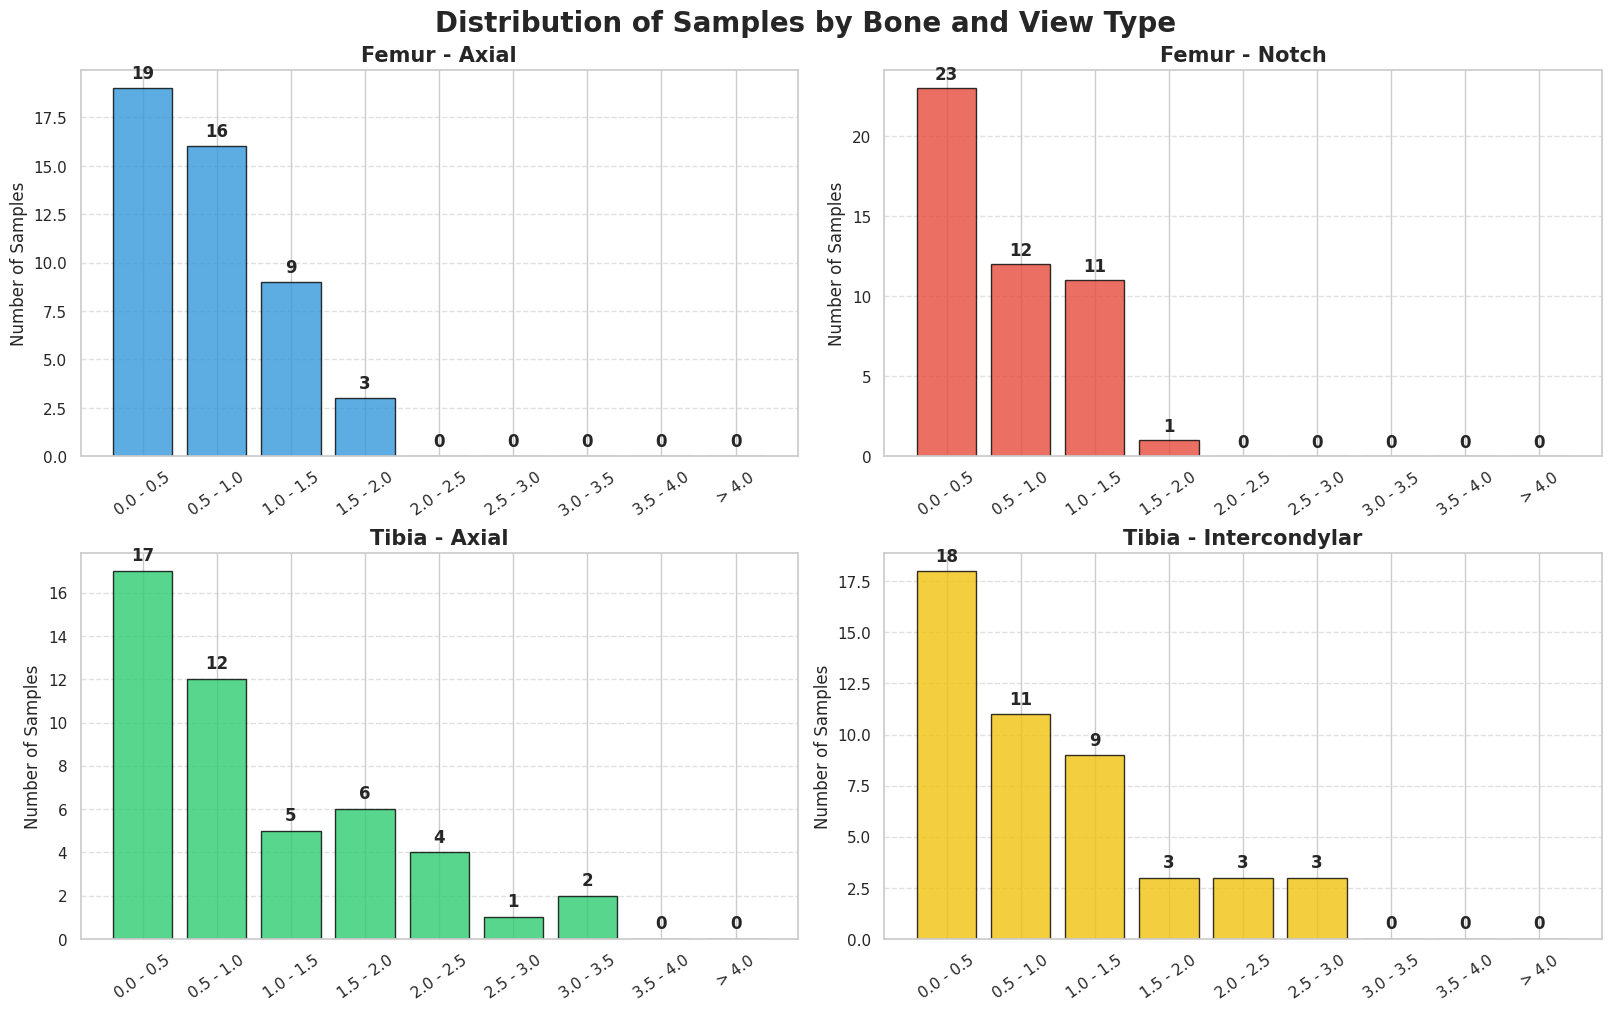

In [15]:
json_data = ""

with open(output_folder + "/distribution.json", "r") as f:
	json_data = json.loads(f.read())
	

def distribution_plot(data):
	fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
	fig.suptitle('Distribution of Samples by Bone and View Type', fontsize=20, fontweight='bold')

	plot_configs = [
		("Femur", "axial", axes[0, 0], "#3498db"),
		("Femur", "notch", axes[0, 1], "#e74c3c"),
		("Tibia", "axial", axes[1, 0], "#2ecc71"),
		("Tibia", "intercondylar", axes[1, 1], "#f1c40f")
	]

	for bone, view, ax, color in plot_configs:
		sub_data = data[bone][view]
		labels = list(sub_data.keys())
		counts = [val["count"] for val in sub_data.values()]
		
		bars = ax.bar(labels, counts, color=color, edgecolor='black', alpha=0.8)
		ax.set_title(f"{bone} - {view.capitalize()}", fontsize=15, fontweight='bold')
		ax.set_ylabel("Number of Samples", fontsize=12)
		ax.tick_params(axis='x', rotation=35)
		ax.grid(axis='y', linestyle='--', alpha=0.6)
		
		for bar in bars:
			yval = bar.get_height()
			ax.text(bar.get_x() + bar.get_width()/2, yval + 0.3, yval, ha='center', va='bottom', fontweight='bold')

	save_path = output_folder + "/" + "distribution_plot.png"
	plt.savefig(save_path, dpi=300)

	print("saved:", save_path)

distribution_plot(json_data)
